# Лабораторная работа: Классификация изображений FaceMask

**Задача:** Бинарная классификация — определение наличия маски на лице.

**Методы:**
1. HOG + SVM (классический метод)
2. CNN с нуля (PyTorch)
3. Transfer Learning (ResNet18)

## 0. Установка зависимостей

In [ ]:
# Для CPU:
!pip install pandas seaborn scikit-image torch torchvision --index-url https://download.pytorch.org/whl/cpu

## 1. Импорт библиотек

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from skimage.feature import hog

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}, Device: {device}')

PyTorch: 2.9.1, Device: cpu


## 2. Загрузка и исследование данных

In [4]:
BASE_DIR = 'Face Mask Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
VAL_DIR = os.path.join(BASE_DIR, 'Validation')
TEST_DIR = os.path.join(BASE_DIR, 'Test')
CLASSES = ['WithMask', 'WithoutMask']

def count_images(directory):
    counts = {}
    for cls in CLASSES:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            counts[cls] = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print('=== Распределение данных ===')
print(f'Train: {train_counts}')
print(f'Validation: {val_counts}')
print(f'Test: {test_counts}')
print(f'Всего: {sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())}')

=== Распределение данных ===
Train: {'WithMask': 5000, 'WithoutMask': 5000}
Validation: {'WithMask': 400, 'WithoutMask': 400}
Test: {'WithMask': 483, 'WithoutMask': 509}
Всего: 11792


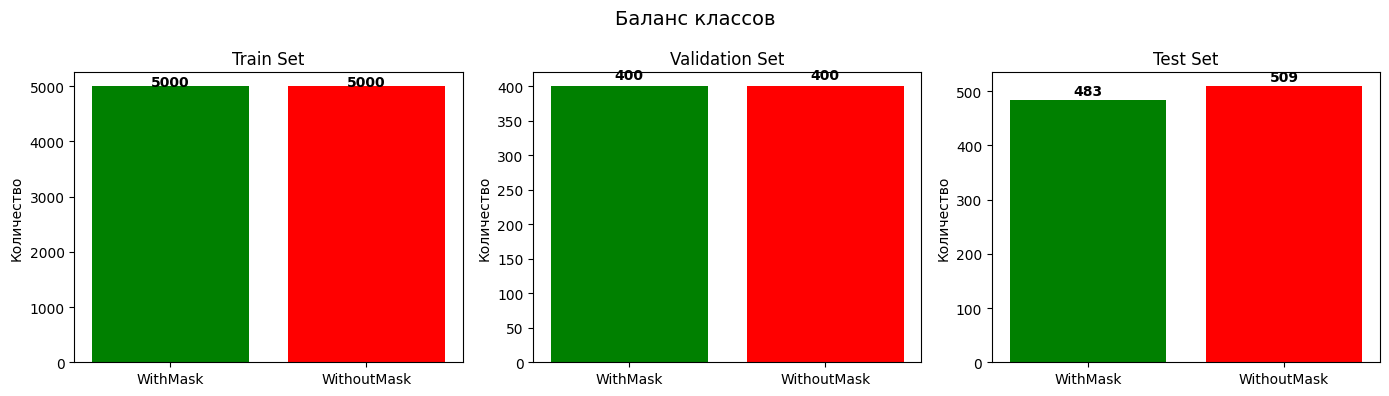

Соотношение классов: 1.00:1
Классы сбалансированы


In [5]:
# Баланс классов
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
datasets = [('Train', train_counts), ('Validation', val_counts), ('Test', test_counts)]

for ax, (name, counts) in zip(axes, datasets):
    ax.bar(counts.keys(), counts.values(), color=['green', 'red'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Количество')
    for i, (k, v) in enumerate(counts.items()):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Баланс классов', fontsize=14)
plt.tight_layout()
plt.show()

total_with = train_counts['WithMask'] + val_counts['WithMask'] + test_counts['WithMask']
total_without = train_counts['WithoutMask'] + val_counts['WithoutMask'] + test_counts['WithoutMask']
ratio = max(total_with, total_without) / min(total_with, total_without)
print(f'Соотношение классов: {ratio:.2f}:1')
print('Дисбаланс!' if ratio > 1.5 else 'Классы сбалансированы')

Ширина: min=26, max=224, mean=152
Высота: min=26, max=224, mean=152


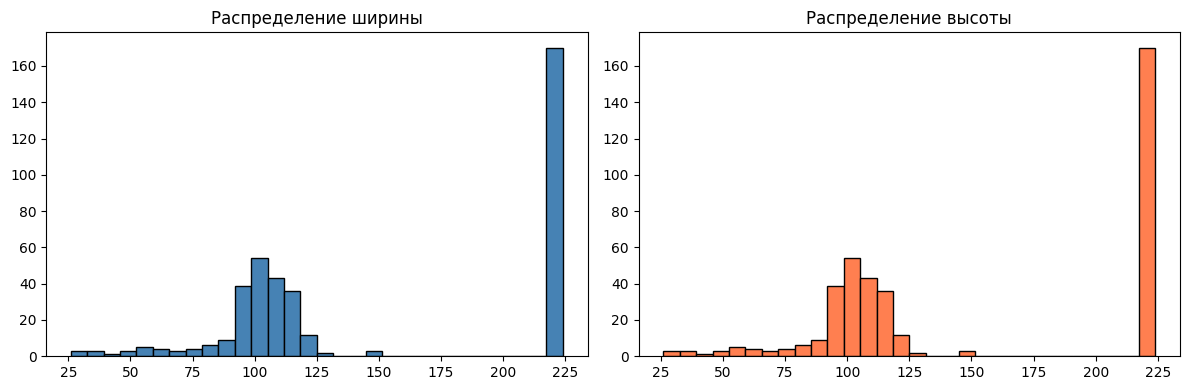

In [6]:
# Анализ размеров
def analyze_images(directory, sample_size=100):
    widths, heights = [], []
    for cls in CLASSES:
        path = os.path.join(directory, cls)
        if not os.path.exists(path): continue
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:sample_size]
        for f in files:
            try:
                img = Image.open(os.path.join(path, f))
                widths.append(img.size[0])
                heights.append(img.size[1])
            except: pass
    return widths, heights

widths, heights = analyze_images(TRAIN_DIR, 200)
print(f'Ширина: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'Высота: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение ширины')
axes[1].hist(heights, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Распределение высоты')
plt.tight_layout()
plt.show()

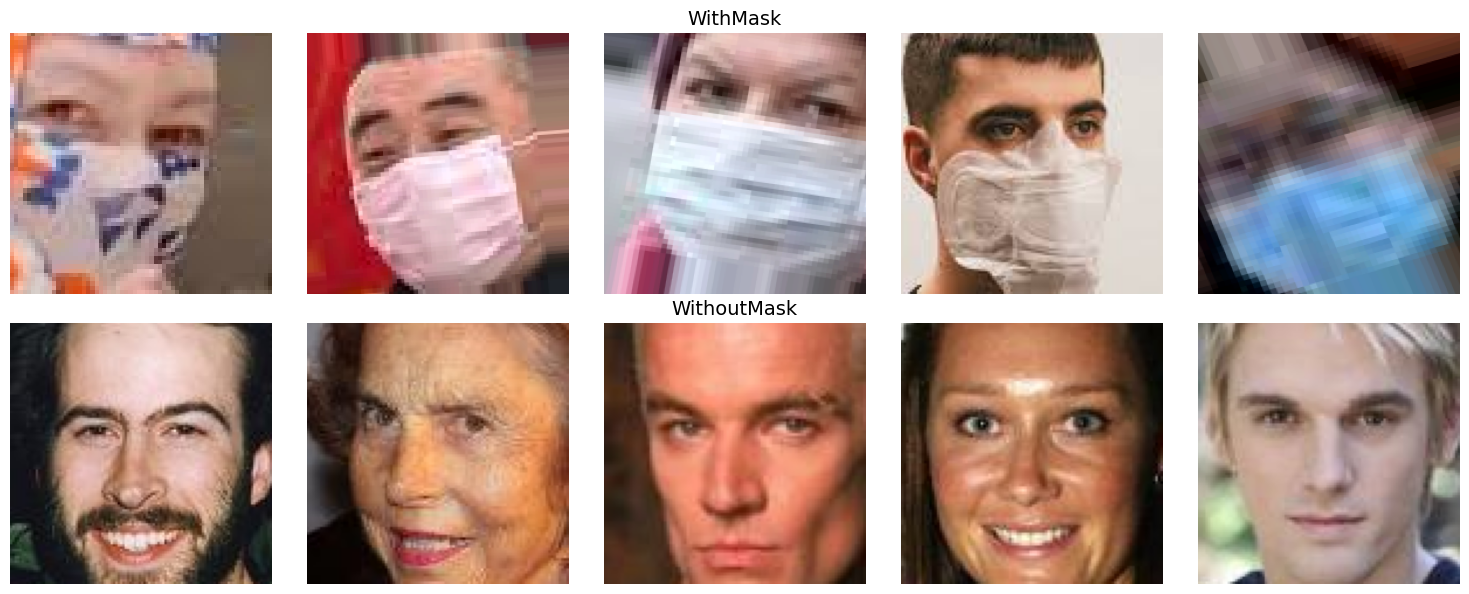

In [7]:
# Примеры изображений
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, cls in enumerate(CLASSES):
    path = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(path)[:5]
    for col, f in enumerate(files):
        img = Image.open(os.path.join(path, f))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
axes[0, 2].set_title('WithMask', fontsize=14)
axes[1, 2].set_title('WithoutMask', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Подготовка данных

In [8]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = ImageFolder(TEST_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Классы: {train_dataset.class_to_idx}')

Классы: {'WithMask': 0, 'WithoutMask': 1}


## 4. Метод 1: HOG + SVM (Классический подход)

In [9]:
# Используем PIL вместо OpenCV (OpenCV плохо работает с кириллицей в путях на Windows)
def extract_hog_features(image_path, img_size=64):
    try:
        img = Image.open(image_path).convert('L')  # Grayscale
        img = img.resize((img_size, img_size))
        img_array = np.array(img)
        features = hog(img_array, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False, feature_vector=True)
        return features
    except:
        return None

def load_hog_data(directory, max_per_class=1000):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        path = os.path.join(directory, cls)
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:max_per_class]
        for f in files:
            features = extract_hog_features(os.path.join(path, f))
            if features is not None:
                X.append(features)
                y.append(label)
    return np.array(X), np.array(y)

print('Извлечение HOG-признаков...')
X_train_hog, y_train_hog = load_hog_data(TRAIN_DIR)
X_test_hog, y_test_hog = load_hog_data(TEST_DIR)
print(f'Train: {X_train_hog.shape}, Test: {X_test_hog.shape}')

Извлечение HOG-признаков...
Train: (2000, 1764), Test: (992, 1764)


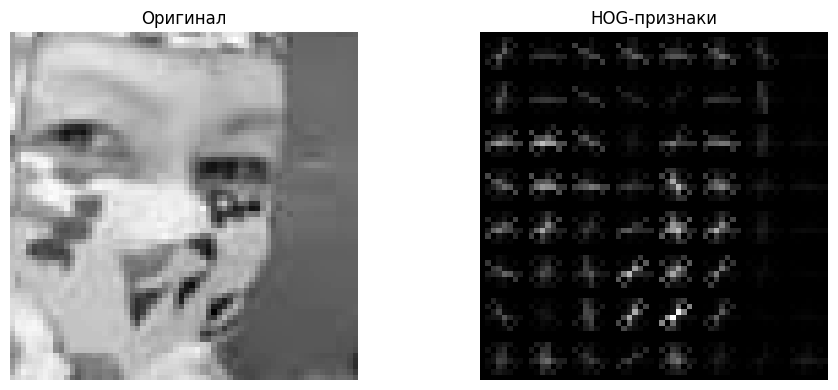

In [10]:
# Визуализация HOG
sample_path = os.path.join(TRAIN_DIR, 'WithMask', os.listdir(os.path.join(TRAIN_DIR, 'WithMask'))[0])
img = Image.open(sample_path).convert('L')
img = img.resize((64, 64))
img_array = np.array(img)
_, hog_image = hog(img_array, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=True, feature_vector=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Оригинал')
axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('HOG-признаки')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
print('Обучение SVM...')
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_hog, y_train_hog)

y_pred_svm = svm_model.predict(X_test_hog)
y_prob_svm = svm_model.predict_proba(X_test_hog)[:, 1]

print('\n=== HOG + SVM Results ===')
print(f'Accuracy: {accuracy_score(y_test_hog, y_pred_svm):.4f}')
print(f'F1-Score: {f1_score(y_test_hog, y_pred_svm):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test_hog, y_prob_svm):.4f}')
print(classification_report(y_test_hog, y_pred_svm, target_names=CLASSES))

Обучение SVM...

=== HOG + SVM Results ===
Accuracy: 0.9798
F1-Score: 0.9801
ROC-AUC: 0.9958
              precision    recall  f1-score   support

    WithMask       0.97      0.99      0.98       483
 WithoutMask       0.99      0.97      0.98       509

    accuracy                           0.98       992
   macro avg       0.98      0.98      0.98       992
weighted avg       0.98      0.98      0.98       992



## 5. Метод 2: CNN с нуля (PyTorch)

**Функция потерь:** Binary Cross-Entropy

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = SimpleCNN().to(device)
print(f'Параметров: {sum(p.numel() for p in cnn_model.parameters()):,}')

Параметров: 8,677,537


In [13]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device)
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += ((outputs > 0.5) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.float().to(device)
                outputs = model(images).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_correct += ((outputs > 0.5) == labels).sum().item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print('Early stopping!')
                break

    model.load_state_dict(torch.load('best_model.pth'))
    return history

In [14]:
print('Обучение CNN...')
history_cnn = train_model(cnn_model, train_loader, val_loader, epochs=30)

Обучение CNN...
Epoch 1/30 - Loss: 0.1386 - Acc: 0.9494 - Val_Loss: 0.0489 - Val_Acc: 0.9862
Epoch 2/30 - Loss: 0.0703 - Acc: 0.9752 - Val_Loss: 0.0279 - Val_Acc: 0.9900
Epoch 3/30 - Loss: 0.0584 - Acc: 0.9789 - Val_Loss: 0.0214 - Val_Acc: 0.9925
Epoch 4/30 - Loss: 0.0479 - Acc: 0.9827 - Val_Loss: 0.0303 - Val_Acc: 0.9900
Epoch 5/30 - Loss: 0.0382 - Acc: 0.9873 - Val_Loss: 0.0289 - Val_Acc: 0.9875
Epoch 6/30 - Loss: 0.0432 - Acc: 0.9831 - Val_Loss: 0.0206 - Val_Acc: 0.9912
Epoch 7/30 - Loss: 0.0339 - Acc: 0.9882 - Val_Loss: 0.0293 - Val_Acc: 0.9888
Epoch 8/30 - Loss: 0.0291 - Acc: 0.9903 - Val_Loss: 0.0143 - Val_Acc: 0.9925
Epoch 9/30 - Loss: 0.0349 - Acc: 0.9868 - Val_Loss: 0.0098 - Val_Acc: 0.9950
Epoch 10/30 - Loss: 0.0340 - Acc: 0.9887 - Val_Loss: 0.0155 - Val_Acc: 0.9938
Epoch 11/30 - Loss: 0.0307 - Acc: 0.9896 - Val_Loss: 0.0129 - Val_Acc: 0.9950
Epoch 12/30 - Loss: 0.0292 - Acc: 0.9907 - Val_Loss: 0.0104 - Val_Acc: 0.9975
Epoch 13/30 - Loss: 0.0229 - Acc: 0.9915 - Val_Loss: 0.00

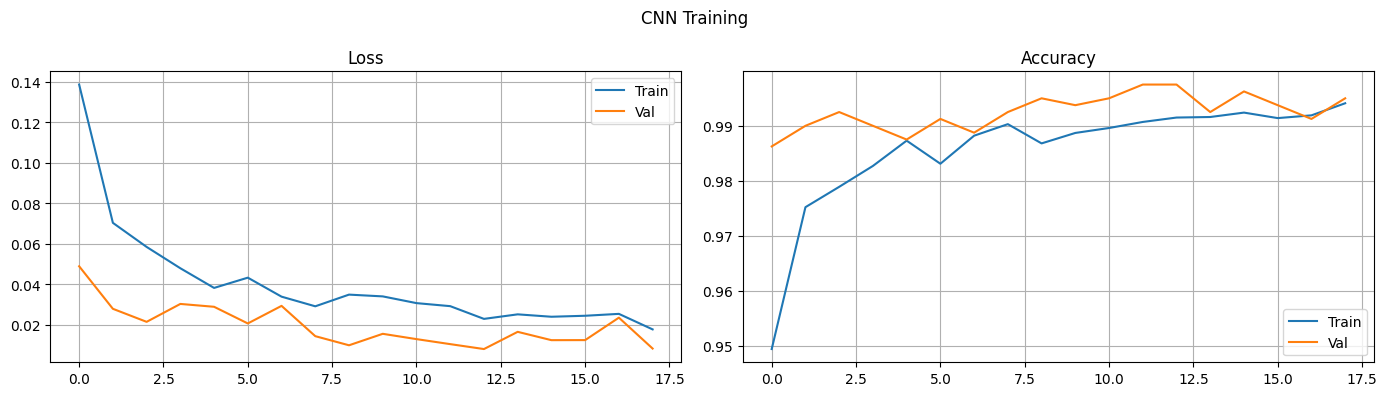

In [15]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, 'CNN Training')

In [16]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device)).squeeze().cpu()
            all_probs.extend(outputs.numpy())
            all_preds.extend((outputs > 0.5).numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true_cnn, y_pred_cnn, y_prob_cnn = evaluate_model(cnn_model, test_loader)

print('=== CNN Results ===')
print(f'Accuracy: {accuracy_score(y_true_cnn, y_pred_cnn):.4f}')
print(f'F1-Score: {f1_score(y_true_cnn, y_pred_cnn):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_true_cnn, y_prob_cnn):.4f}')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASSES))

=== CNN Results ===
Accuracy: 0.9970
F1-Score: 0.9971
ROC-AUC: 0.9998
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



## 6. Метод 3: Transfer Learning (ResNet18)

In [17]:
resnet_model = models.resnet18(weights='IMAGENET1K_V1')
for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 1), nn.Sigmoid()
)
resnet_model = resnet_model.to(device)
print(f'Обучаемых параметров: {sum(p.numel() for p in resnet_model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/belovegor/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Обучаемых параметров: 131,585


In [18]:
print('Обучение ResNet18...')
history_resnet = train_model(resnet_model, train_loader, val_loader, epochs=20)

Обучение ResNet18...
Epoch 1/20 - Loss: 0.1658 - Acc: 0.9331 - Val_Loss: 0.1116 - Val_Acc: 0.9563
Epoch 2/20 - Loss: 0.1041 - Acc: 0.9613 - Val_Loss: 0.0563 - Val_Acc: 0.9825
Epoch 3/20 - Loss: 0.1023 - Acc: 0.9611 - Val_Loss: 0.0821 - Val_Acc: 0.9625
Epoch 4/20 - Loss: 0.0976 - Acc: 0.9616 - Val_Loss: 0.0589 - Val_Acc: 0.9775
Epoch 5/20 - Loss: 0.0913 - Acc: 0.9658 - Val_Loss: 0.0469 - Val_Acc: 0.9812
Epoch 6/20 - Loss: 0.0775 - Acc: 0.9703 - Val_Loss: 0.0641 - Val_Acc: 0.9750
Epoch 7/20 - Loss: 0.0820 - Acc: 0.9683 - Val_Loss: 0.0465 - Val_Acc: 0.9812
Epoch 8/20 - Loss: 0.0816 - Acc: 0.9696 - Val_Loss: 0.0547 - Val_Acc: 0.9812
Epoch 9/20 - Loss: 0.0790 - Acc: 0.9690 - Val_Loss: 0.0369 - Val_Acc: 0.9862
Epoch 10/20 - Loss: 0.0674 - Acc: 0.9746 - Val_Loss: 0.0491 - Val_Acc: 0.9812
Epoch 11/20 - Loss: 0.0786 - Acc: 0.9715 - Val_Loss: 0.0380 - Val_Acc: 0.9838
Epoch 12/20 - Loss: 0.0707 - Acc: 0.9752 - Val_Loss: 0.0361 - Val_Acc: 0.9838
Epoch 13/20 - Loss: 0.0667 - Acc: 0.9741 - Val_Loss:

In [19]:
# Fine-tuning
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

print('Fine-tuning...')
history_resnet_ft = train_model(resnet_model, train_loader, val_loader, epochs=10, lr=0.0001)

Fine-tuning...
Epoch 1/10 - Loss: 0.0391 - Acc: 0.9886 - Val_Loss: 0.0007 - Val_Acc: 1.0000
Epoch 2/10 - Loss: 0.0097 - Acc: 0.9961 - Val_Loss: 0.0119 - Val_Acc: 0.9950
Epoch 3/10 - Loss: 0.0091 - Acc: 0.9971 - Val_Loss: 0.0001 - Val_Acc: 1.0000
Epoch 4/10 - Loss: 0.0062 - Acc: 0.9974 - Val_Loss: 0.0003 - Val_Acc: 1.0000
Epoch 5/10 - Loss: 0.0055 - Acc: 0.9985 - Val_Loss: 0.0003 - Val_Acc: 1.0000
Epoch 6/10 - Loss: 0.0041 - Acc: 0.9985 - Val_Loss: 0.0000 - Val_Acc: 1.0000
Epoch 7/10 - Loss: 0.0039 - Acc: 0.9990 - Val_Loss: 0.0000 - Val_Acc: 1.0000
Epoch 8/10 - Loss: 0.0035 - Acc: 0.9995 - Val_Loss: 0.0000 - Val_Acc: 1.0000
Epoch 9/10 - Loss: 0.0043 - Acc: 0.9989 - Val_Loss: 0.0080 - Val_Acc: 0.9975
Epoch 10/10 - Loss: 0.0143 - Acc: 0.9984 - Val_Loss: 0.0020 - Val_Acc: 1.0000


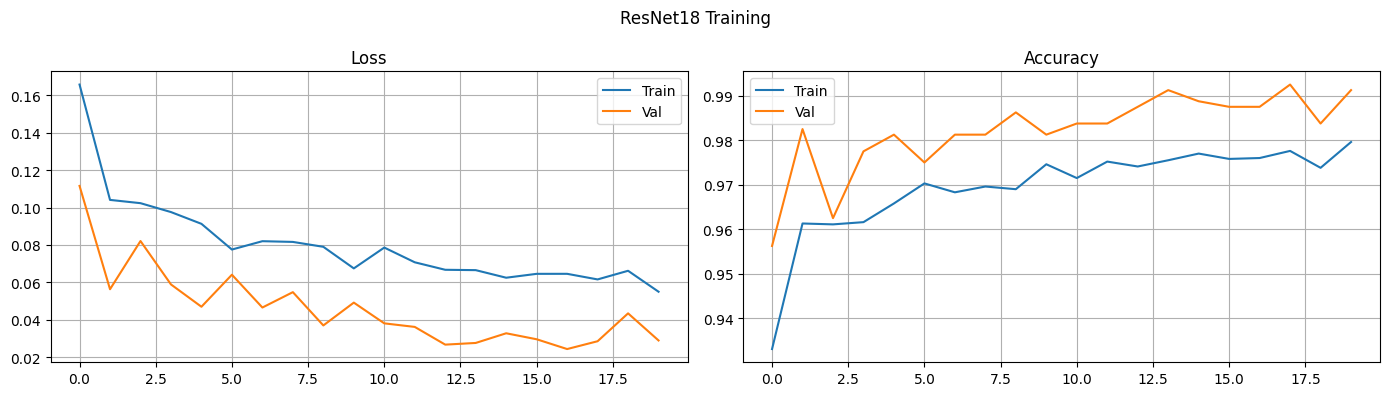

In [20]:
plot_history(history_resnet, 'ResNet18 Training')

In [21]:
y_true_resnet, y_pred_resnet, y_prob_resnet = evaluate_model(resnet_model, test_loader)

print('=== ResNet18 Results ===')
print(f'Accuracy: {accuracy_score(y_true_resnet, y_pred_resnet):.4f}')
print(f'F1-Score: {f1_score(y_true_resnet, y_pred_resnet):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_true_resnet, y_prob_resnet):.4f}')
print(classification_report(y_true_resnet, y_pred_resnet, target_names=CLASSES))

=== ResNet18 Results ===
Accuracy: 0.9990
F1-Score: 0.9990
ROC-AUC: 1.0000
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



## 7. Сравнение моделей

In [22]:
results = {
    'Model': ['HOG + SVM', 'CNN', 'ResNet18'],
    'Accuracy': [
        accuracy_score(y_test_hog, y_pred_svm),
        accuracy_score(y_true_cnn, y_pred_cnn),
        accuracy_score(y_true_resnet, y_pred_resnet)
    ],
    'F1-Score': [
        f1_score(y_test_hog, y_pred_svm),
        f1_score(y_true_cnn, y_pred_cnn),
        f1_score(y_true_resnet, y_pred_resnet)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_hog, y_prob_svm),
        roc_auc_score(y_true_cnn, y_prob_cnn),
        roc_auc_score(y_true_resnet, y_prob_resnet)
    ]
}

results_df = pd.DataFrame(results).round(4)
print('=== Сравнение моделей ===')
print(results_df.to_string(index=False))

=== Сравнение моделей ===
    Model  Accuracy  F1-Score  ROC-AUC
HOG + SVM    0.9798    0.9801   0.9958
      CNN    0.9970    0.9971   0.9998
 ResNet18    0.9990    0.9990   1.0000


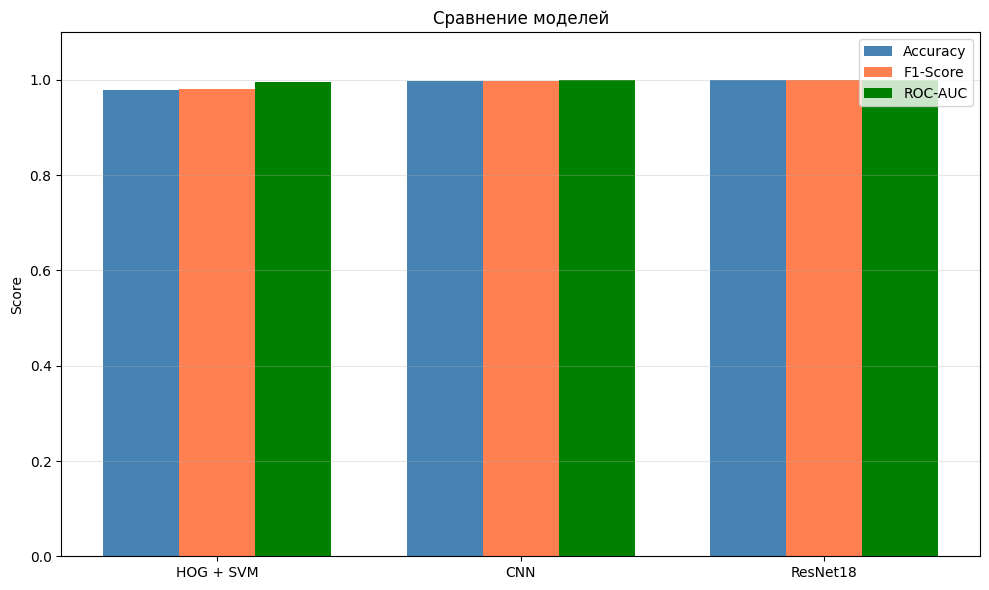

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.25

ax.bar(x - width, results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x, results['F1-Score'], width, label='F1-Score', color='coral')
ax.bar(x + width, results['ROC-AUC'], width, label='ROC-AUC', color='green')

ax.set_ylabel('Score')
ax.set_title('Сравнение моделей')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

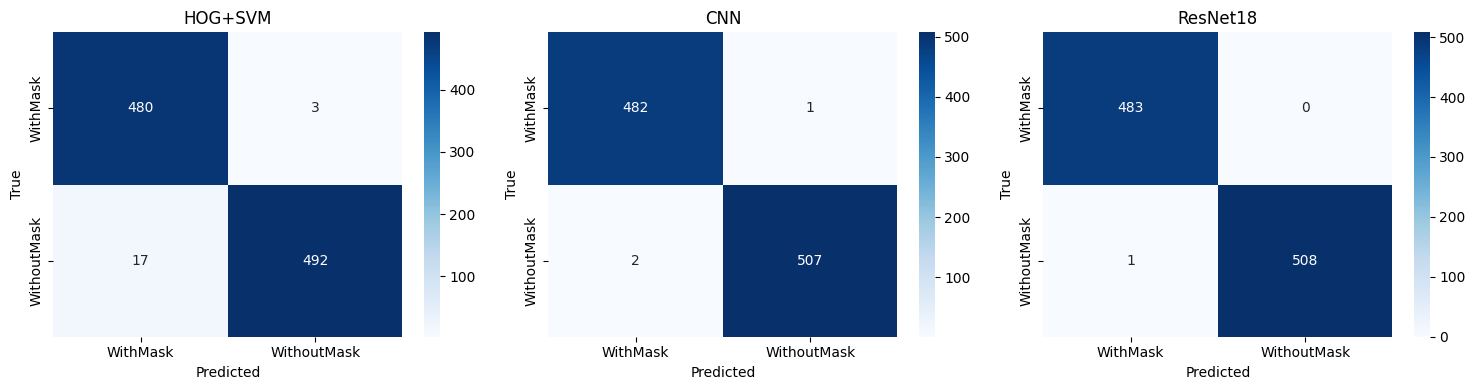

In [24]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cms = [
    ('HOG+SVM', confusion_matrix(y_test_hog, y_pred_svm)),
    ('CNN', confusion_matrix(y_true_cnn, y_pred_cnn)),
    ('ResNet18', confusion_matrix(y_true_resnet, y_pred_resnet))
]
for ax, (name, cm) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

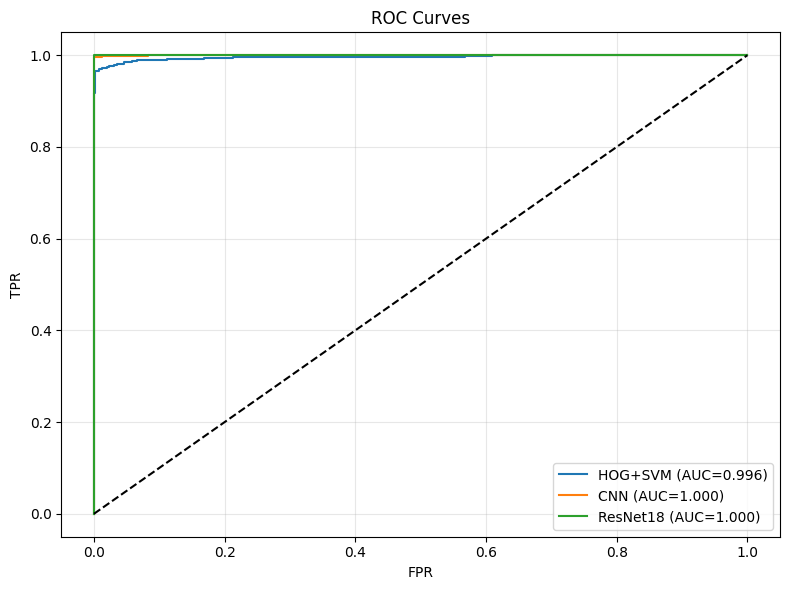

In [25]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob in [('HOG+SVM', y_test_hog, y_prob_svm),
                              ('CNN', y_true_cnn, y_prob_cnn),
                              ('ResNet18', y_true_resnet, y_prob_resnet)]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_true, y_prob):.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Выводы

### Методы:
1. **HOG + SVM** — классический метод, быстрый, но менее точный
2. **CNN** — нейросеть с нуля, хорошая точность
3. **ResNet18** — transfer learning, лучшие результаты

### Функция потерь: Binary Cross-Entropy

### Метрики: Accuracy, F1-Score, ROC-AUC

In [26]:
best_idx = results_df['F1-Score'].idxmax()
best = results_df.loc[best_idx]
print('=' * 40)
print(f'ЛУЧШАЯ МОДЕЛЬ: {best["Model"]}')
print(f'Accuracy: {best["Accuracy"]:.4f}')
print(f'F1-Score: {best["F1-Score"]:.4f}')
print(f'ROC-AUC: {best["ROC-AUC"]:.4f}')
print('=' * 40)

ЛУЧШАЯ МОДЕЛЬ: ResNet18
Accuracy: 0.9990
F1-Score: 0.9990
ROC-AUC: 1.0000


In [27]:
# Сохранение всех моделей для телеграм-бота
import joblib

# Модель 1: HOG + SVM
joblib.dump(svm_model, 'model_1_svm.pkl')
print('Модель 1 (HOG+SVM) сохранена: model_1_svm.pkl')

# Модель 2: CNN
torch.save(cnn_model.state_dict(), 'model_2_cnn.pth')
print('Модель 2 (CNN) сохранена: model_2_cnn.pth')

# Модель 3: ResNet18
torch.save(resnet_model.state_dict(), 'model_3_resnet18.pth')
print('Модель 3 (ResNet18) сохранена: model_3_resnet18.pth')

# Лучшая модель (копия лучшей по F1-Score)
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
if 'SVM' in best_model_name:
    joblib.dump(svm_model, 'best_model.pkl')
    print(f'Лучшая модель ({best_model_name}) сохранена: best_model.pkl')
elif 'CNN' in best_model_name and 'ResNet' not in best_model_name:
    torch.save(cnn_model.state_dict(), 'best_model.pth')
    print(f'Лучшая модель ({best_model_name}) сохранена: best_model.pth')
else:
    torch.save(resnet_model.state_dict(), 'best_model.pth')
    print(f'Лучшая модель ({best_model_name}) сохранена: best_model.pth')

print('\nВсе модели готовы для использования в телеграм-боте!')

Модель 1 (HOG+SVM) сохранена: model_1_svm.pkl
Модель 2 (CNN) сохранена: model_2_cnn.pth
Модель 3 (ResNet18) сохранена: model_3_resnet18.pth
Лучшая модель (ResNet18) сохранена: best_model.pth

Все модели готовы для использования в телеграм-боте!
